### Running cell2location to map our 10X Genomics Bleo day21 data to publicly available 10X Visium Bleo day21 data

ST data from [Franzen, Lindvall, et al. Nature Genetics (2024)](https://www.nature.com/articles/s41588-024-01819-2)

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sb

In [2]:
import cell2location as c2l

/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [3]:
# making sure plots & clusters are reproducible
np.random.seed(42)

In [4]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig_spatial_overview/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [45]:
## path variables
sc_dir = '/mnt/smb2/Niklas/GLPG_data_temp/240913_GLPG_PBS_Bleo_d21.h5ad'
spatial_dir = '/mnt/smb2/Niklas/20240911_10XVisum_Stockholm_mouse/240919_10XVisium_d21.h5ad'
data_dir = '/mnt/smb2/Niklas/20240911_10XVisum_Stockholm_mouse'

In [46]:
## paths reference regression and cell2location models
ref_run_name = f'{data_dir}/reference_signatures'
run_name = f'{data_dir}/cell2location_map'

### Load Visium data

In [7]:
adata_st = sc.read(spatial_dir)

### Load scRNA-seq reference data

In [8]:
adata_sc = sc.read(sc_dir)

In [9]:
adata_sc

AnnData object with n_obs × n_vars = 72828 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'disper

### Map Gene Symbols to ENSEMBL IDs for correct matching between single cell and spatial data

In [10]:
## store gene symbols in dedicated adata.var column
adata_sc.var['SYMBOL'] = adata_sc.var.index

In [11]:
import mygene

In [12]:
## initialize mygene object
mg = mygene.MyGeneInfo()

In [13]:
## query MyGene to map gene symbols to ENSEMBL IDs
gene_symbols = adata_sc.var['SYMBOL'].tolist()
query_results = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='mouse')

2301 input query terms found dup hits:	[('Gm19938', 2), ('Gm6085', 2), ('4732440D04Rik', 2), ('Gm37108', 2), ('Gm26901', 2), ('2610203C22Ri
2201 input query terms found no hit:	['Fam150a', '4931428L18Rik', '2010300C02Rik', '1500015O10Rik', 'Gm8251', 'Kdelc1', 'Sdpr', 'Gm45679'


In [14]:
## convert results into a dictionary {gene_symbol: ensembl_id}
symbol_to_ensembl = {}
for res in query_results:
    if 'ensembl' in res:
        ensembl_data = res['ensembl']
        
        # If ensembl_data is a list (multiple mappings), take the first entry
        if isinstance(ensembl_data, list):
            ensembl_id = ensembl_data[0].get('gene')  # Get the 'gene' field from the first entry
        else:
            ensembl_id = ensembl_data.get('gene')  # Directly get the 'gene' field if it's a dictionary

        symbol_to_ensembl[res['query']] = ensembl_id

In [15]:
## add ENSEMBL IDs to your adata_ref.var
adata_sc.var['ENSEMBL_ID'] = adata_sc.var['SYMBOL'].map(symbol_to_ensembl)

In [16]:
## remove genes without for which ENSEMBL mapping didn't work
print(f'No. of genes before: {adata_sc.shape[1]}')
adata_sc = adata_sc[:, adata_sc.var['ENSEMBL_ID'].notna()]
print(f'No. of genes after: {adata_sc.shape[1]}')

No. of genes before: 24500
No. of genes after: 22175


In [17]:
## set ENSEMBL IDs as index
adata_sc.var.set_index('ENSEMBL_ID', drop=True, inplace=True)

In [18]:
## delete unnecessary raw slot (to be removed in a future version of the tutorial)
del adata_sc.raw

### Filter genes

In [19]:
## first: subset both datasets to the same gene set  (baseline for mapping between the single cell and spatial data)
shared_features = [
    feature for feature in adata_st.var_names if feature in adata_sc.var_names
]
adata_sc = adata_sc[:, shared_features].copy()
adata_st = adata_st[:, shared_features].copy()

/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


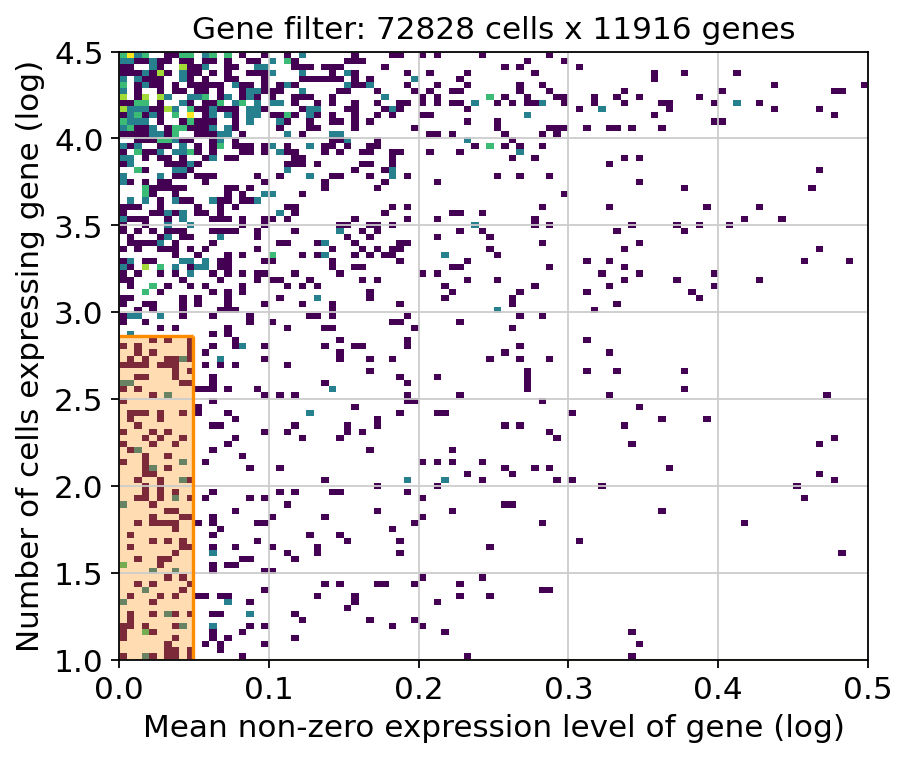

In [20]:
## filter genes
selected = c2l.utils.filtering.filter_genes(adata_sc,
                        cell_count_cutoff = 5,
                        cell_percentage_cutoff2 = 0.01,
                        nonz_mean_cutoff = 1.12)

In [21]:
## subset both AnnData objects to the selected genes
adata_sc = adata_sc[:, selected].copy()
adata_st = adata_st[:, selected].copy()

### Estimation of reference cell type signatures (NB regression)

In [22]:
## prepare anndata for the regression model
c2l.models.RegressionModel.setup_anndata(adata=adata_sc,
                                         layer = 'counts',
                                         ## 10X reaction / sample / batch
                                         batch_key = 'SeqBatch',
                                         ## cell type, covariate used for constructing signatures
                                         labels_key = 'cell_type',
                                         # multiplicative technical effects (platform, 3' vs 5', donor effect)
                                         categorical_covariate_keys=['treatment']
                                        )

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [23]:
## create the regression model
model = c2l.models.RegressionModel(adata_sc)

In [24]:
## view anndata_setup as a sanity check
model.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': 'SeqBatch',
│   'labels_key': 'cell_type',
│   'categorical_covariate_keys': ['treatment'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   7   │
│         n_cells          │ 72828 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  64   │
│          n_vars          │ 11916 │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │           adata.layers['counts']           │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                    batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['SeqBatch'] │    Seq1    │          0          │
│                       │    Seq2    │          1          │
│                       │    Seq3    │          2          │
│                       │    Seq4    │          3          │
│                       │    Seq5    │          4          │
│                       │    Seq6    │          5          │
│                       │    Seq7    │          6          │
└───────────────────────┴────────────┴─────────────────────┘

                                labels State Registry                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃             Categories              ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_type'] │                 AT1                 │          0          │
│                        │                 AT2                 │          1          │
│                        │            AT2 activated            │          2          │
│                        │              Krt8+ ADI              │          3          │
│                        │                Basal                │          4          │
│                        │            Club/Ciliated            │          5          │
│                        │              Ciliated               │          6          │
│                        │                 NEC                 │          7          │
│                        │        Aerocyte capillary EC        │          8          │
│                        │      Transitional capillary EC      │          9          │
│                        │        General capillary EC         │         10          │
│                        │     Proliferating capillary EC      │         11          │
│                        │ Vwa1+/Col15a1+ ectopic capillary EC │         12          │
│                        │             Arterial EC             │         13          │
│                        │              Venous EC              │         14          │
│                        │            Lymphatic EC             │         15          │
│                        │       Adventitial Fibroblasts       │         16          │
│                        │          Adh7+ Fibroblasts          │         17          │
│                        │       Lgr5+/Lgr6+ Fibroblasts       │         18          │
│                        │  Lgr5+/Lgr6+ Fibroblasts activated  │         19          │
│                        │           Lipofibroblasts           │         20          │
│                        │    Lipo/Myofibroblast Transition    │         21          │
│                        │       Cthrc1+ Myofibroblasts        │         22          │
│                        │        Spp1+ Myofibroblasts         │         23          │
│                        │              Pericytes              │         24          │
│                        │         Pericytes activated         │         25          │
│                        │                aSMCs                │         26          │
│                        │                vSMCs                │         27          │
│                        │             Mesothelial             │         28          │
│                        │       Non-classical Monocytes       │         29          │
│                        │         Classical Monocytes         │         30          │
│                        │       Intermediate Monocytes        │         31          │
│                        │       Transitional Monocytes        │         32          │
│                        │           M2 Macrophages            │         33          │
│                        │                 AM                  │         34          │
│                        │          Proliferating AM           │         35          │
│                        │              Prg4+ IM               │         36          │
│                        │          Lyve1+/Cd163+ IM           │         37          │
│                        │          Lyve1-/Cd163- IM           │         38          │
│                        │          Proliferating IM           │         39          │
│                        │                cDC1                 │         40          │
│                        │                cDC2                 │         41          

            extra_categorical_covs State Registry            
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['treatment'] │    Bleo    │          0          │
│                        │    PBS     │          1          │
│                        │            │                     │
└────────────────────────┴────────────┴─────────────────────┘

In [34]:
##  train the model to estimate the reference cell type signatures
use_gpu = False
model.train(max_epochs=250, batch_size=2500, train_size=1, lr=0.002, use_gpu=False)

/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/scvi/train/_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/lightning/pytorch/trainer/setup.py:176: GPU available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='gpu', devices=1)`.
/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.


Epoch 250/250: 100%|█| 250/250 [2:32:53<00:00, 36.53s/it, v_num=1, elbo_train=3.

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|█| 250/250 [2:32:53<00:00, 36.69s/it, v_num=1, elbo_train=3.


In [38]:
## check what is stored in history 
model.history_.keys()

dict_keys(['elbo_train'])

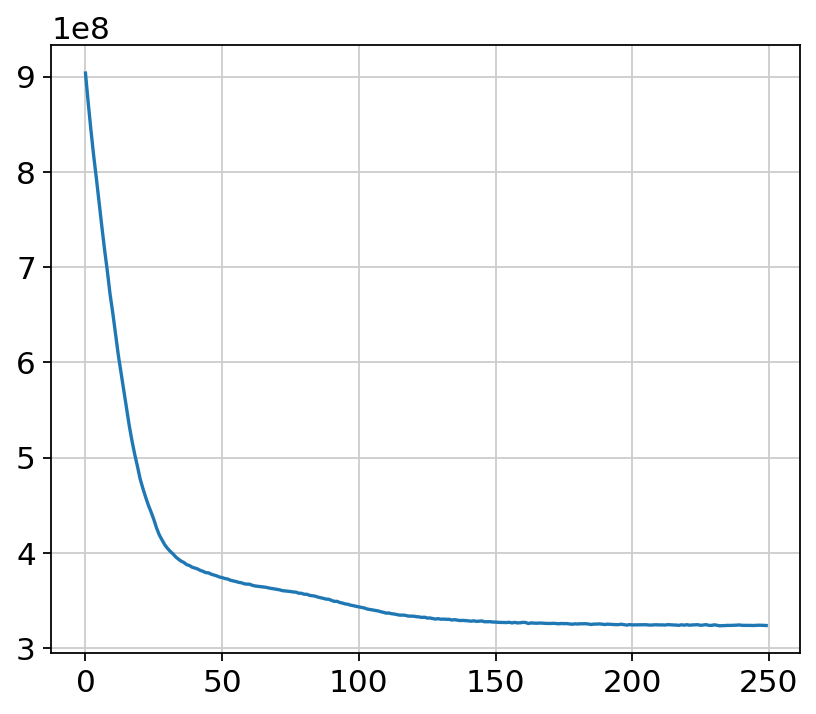

In [41]:
## plot ELBO loss history during training
ax = plt.gca()
ax.plot(
    np.array(model.history_['elbo_train'].index[0:250]),
    np.array(model.history_['elbo_train'].values.flatten()[0:250]),
    label="train",
)

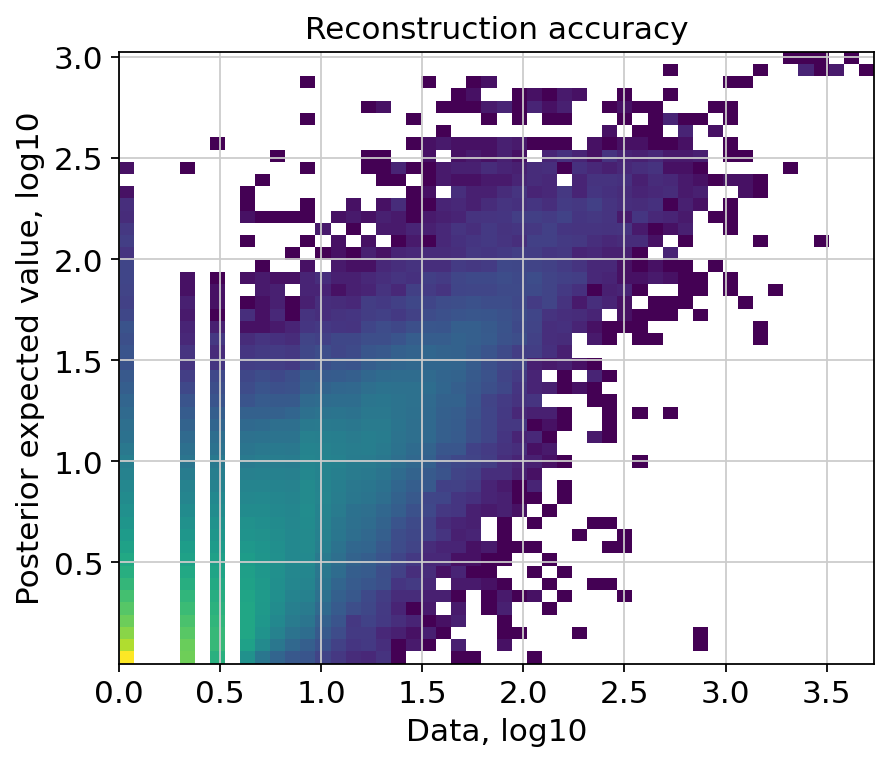

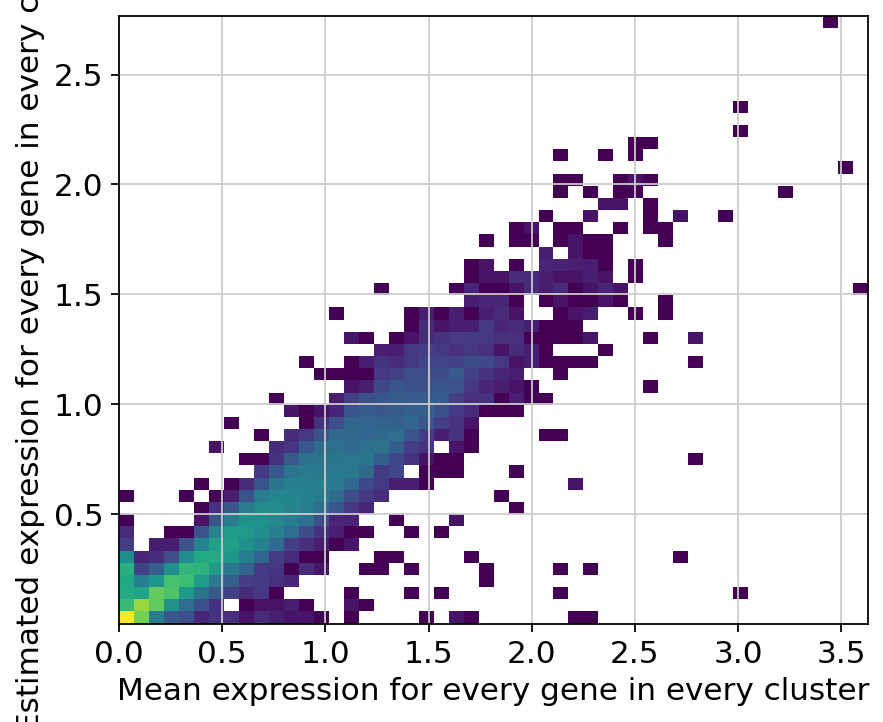

In [49]:
model.plot_QC()

### Save results

In [42]:
## export estimated cell abundance (summary of the posterior distribution)
adata_sc = model.export_posterior(
    adata_sc, sample_kwargs={'num_samples': 1000, 'batch_size': 2500, 'use_gpu': False}
)

/home/niklas/miniconda3/envs/st_env/lib/python3.9/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling global variables, sample: 100%|██████| 999/999 [02:25<00:00,  6.85it/s]


In [48]:
## save anndata object with results
adata_file = f"{ref_run_name}/240923_GLPG_PBS_Bleo_d21_reference_signatures.h5ad"
adata_sc.write(adata_file)
adata_file

'/mnt/smb2/Niklas/20240911_10XVisum_Stockholm_mouse//reference_signatures/240923_GLPG_PBS_Bleo_d21_reference_signatures.h5ad'

In [51]:
## save model
model.save(f"{ref_run_name}", overwrite=True)